In [98]:
from qiskit import QuantumCircuit
import qiskit.quantum_info as qi
from qiskit.visualization import array_to_latex , plot_bloch_vector, plot_bloch_multivector
import numpy as np

In [99]:
psi0 = qi.Statevector([0,1,0,0])
psi0.draw("latex")

<IPython.core.display.Latex object>

In [100]:
qc = QuantumCircuit(2)
qc.h(1)
qc.cx(1, 0)
qc.draw(reverse_bits=True)

┌───┐     
q_1: ┤ H ├──■──
     └───┘┌─┴─┐
q_0: ─────┤ X ├
          └───┘

In [101]:
psi1 = psi0.evolve(qc)
psi1.draw("latex")

<IPython.core.display.Latex object>

In [102]:
rho1 = qi.DensityMatrix(psi1)
rho1.draw("latex")

<IPython.core.display.Latex object>

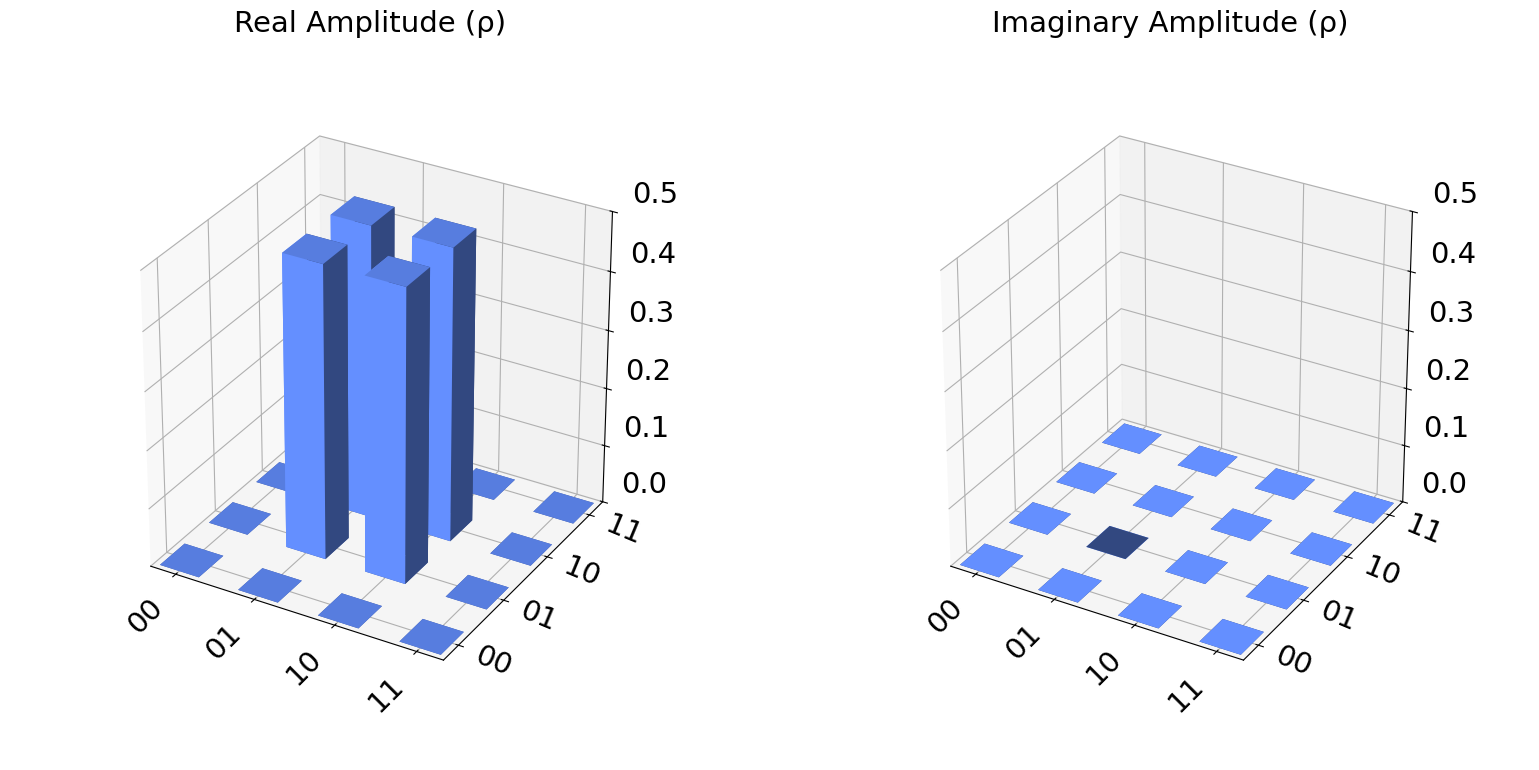

In [103]:
rho1.draw("city")

In [104]:
rho2 = qi.DensityMatrix.from_label("l")
# rho2.draw("latex")
array_to_latex(rho2) # Can use any, same results.

<IPython.core.display.Latex object>

### Representing it on  Bloch Sphere

#### Density Matrix $\rightarrow$ Bloch Sphere

For a qubit density matrix:

$$\rho = \begin{pmatrix} \rho_{00} & \rho_{01} \\ \rho_{10} & \rho_{11} \end{pmatrix}$$

Bloch vector components are:

$$x = 2 \operatorname{Re}(\rho_{01})$$
$$y = 2 \operatorname{Im}(\rho_{10})$$
$$z = \rho_{00} - \rho_{11}$$

So Bloch vector:

$$\vec{r} = (x, y, z)$$

In [105]:
# Method 1
bs = rho2

# Bloch Vector
x = 2 * np.real(bs.data[0,1])
y = 2 * np.imag(bs.data[1,0])
z = 2 * np.real(bs.data[0,0] - bs.data[1,1])

# plot_bloch_vector([x, y, z])

In [106]:
# Method 2

# plot_bloch_multivector(bs)

In [107]:
S = qi.Operator.from_label("S")
S.draw("latex")

<IPython.core.display.Latex object>

In [108]:
rho3 = rho2.evolve(S)
rho3.draw("latex")

<IPython.core.display.Latex object>

In [109]:
# plot_bloch_multivector(rho3)

In [111]:
rho4 = 1/3*qi.DensityMatrix.from_label('0') + 2/3*qi.DensityMatrix.from_label('1')
rho4.draw("latex")

<IPython.core.display.Latex object>

In [114]:
rho4.evolve(qi.Operator.from_label('X')).draw("latex")

<IPython.core.display.Latex object>